# Helmholtz Equation testing


Import the necessary packages

In [1]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns

### 1D Helmholtz Equation: Finite Difference Derivation

The Helmholtz equation in 1D is:

$$
\frac{d^2u}{dx^2} + k^2u = f(x)
$$

#### Discretization
- Domain: Split into $ N $ interior points with grid spacing $ h = \frac{1}{N+1} $.
- Let $ u_i \approx u(x_i) $ and $ f_i = f(x_i) $, where $ x_i = ih $.

#### Central Difference Approximation
The second derivative is approximated as:

$$
\frac{d^2u}{dx^2} \bigg|_{x_i} \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}
$$

#### Substituting into the Helmholtz Equation
$$
\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + k^2u_i = f_i
$$

Rearranging terms gives the linear equation for interior points:

$$
\frac{1}{h^2}u_{i-1} + \left( \frac{-2}{h^2} + k^2 \right)u_i + \frac{1}{h^2}u_{i+1} = f_i
$$

#### Matrix Form $ A\mathbf{u} = \mathbf{f} $
For Dirichlet boundary conditions ($ u_0 = u_{N+1} = 0 $), the resulting tridiagonal matrix $ A $ is:

$$
A = \begin{bmatrix}
\frac{-2}{h^2} + k^2 & \frac{1}{h^2} & 0 & \cdots & 0 \\
\frac{1}{h^2} & \frac{-2}{h^2} + k^2 & \frac{1}{h^2} & \cdots & 0 \\
0 & \frac{1}{h^2} & \frac{-2}{h^2} + k^2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \frac{1}{h^2} \\
0 & 0 & 0 & \frac{1}{h^2} & \frac{-2}{h^2} + k^2
\end{bmatrix}
$$

**Summary**:  
The matrix $ A $ is tridiagonal with:
- Diagonal entries: $ \frac{-2}{h^2} + k^2 $
- Off-diagonal entries: $ \frac{1}{h^2} $


## Quick Quantum implementation for a sine function

Proceed first to build the matrix A and implement the boundary conditions

In [7]:
# Build the matrix A
NUM_QUBITS = 2
MATRIX_SIZE = 2 ** NUM_QUBITS

L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 1.0                                     # Wavenumber (avoid k = nπ for stability!)
eps = 0.0001                                # Error tolerance
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points


a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

x = np.linspace(0, 1, N+2)[1:-1]  # Interior points (Dirichlet BCs)
vector = ( k**2 - np.pi**2) * np.sin(np.pi * x) 

print('matrix\n' , matrix)
print('vector\n', vector)
print('matrix condition number:', np.linalg.cond(matrix))


matrix
 [[-49.  25.   0.   0.]
 [ 25. -49.  25.   0.]
 [  0.  25. -49.  25.]
 [  0.   0.  25. -49.]]
vector
 [-5.21342266 -8.43549506 -8.43549506 -5.21342266]
matrix condition number: 10.463127536183748


Thomas algorithm solver (classical solver comparison)

In [8]:
# import sys
# # Add the path to the folder containing numerical_solvers
# sys.path.append("..")

from numerical_solvers.thomas_algorithm import numerical_solvers

num_solve = numerical_solvers()
num_solution = num_solve.solve_tridiagonal_thomas(matrix, vector)


Quantum solution

In [9]:
# Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)
print(' No. of trotter steps used:', tridi_mat.trotter_steps)

# Tridiagonal Toeplitz HHL
tridi_hhl = HHL()
tridi_solution = tridi_hhl.solve(tridi_mat, vector)


 No. of trotter steps used: 1
hello

 Number of ancilla qubits 
:  1

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  2


### Evaluation
All of the code will be compared to a normalised output solution. Thereby meaning that all of the values will be normalized and won't actually represent the solution amplitudes.

In [10]:
# explicit function to normalize array
def normalize(arr, t_min, t_max):
    norm_arr = []
    diff = t_max - t_min
    diff_arr = max(arr) - min(arr)
    for i in arr:
        temp = (((i - min(arr))*diff)/diff_arr) + t_min
        norm_arr.append(temp)
    return norm_arr

def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm * solution_vector / np.linalg.norm(solution_vector)

tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
tridi_vector = np.concatenate(([0], tridi_vector, [0]))
tridi_vector = normalize(tridi_vector, 0, 1)


Thomas Mean Absolute Error: 0.028840771790041214
HHL Mean Absolute Error: 0.03927693080665498


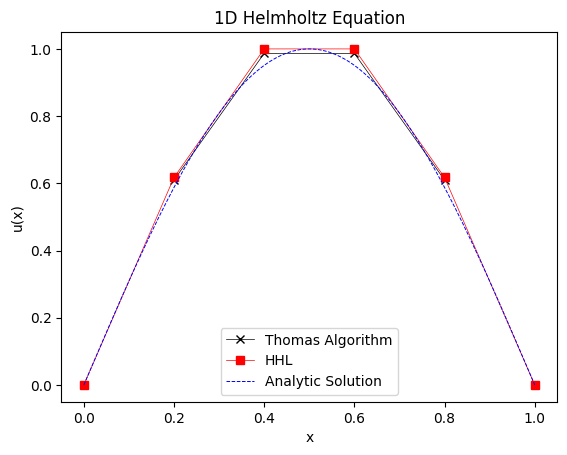

: 

In [11]:
x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
u_analytic = np.sin(np.pi * x_fine)
u_error = np.sin(np.pi * x_numerical)

real_domain = np.concatenate(([0], x_numerical, [L]))

# Plot the results
plt.plot(x_numerical, num_solution, color='k', linewidth=0.5, marker='x',label='Thomas Algorithm')
plt.plot(real_domain , tridi_vector ,linewidth=0.5, color='r', marker='s' ,label='HHL')
# plot analytic solution
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('1D Helmholtz Equation')
plt.legend()

# plt.savefig('1D_Helmholtz.png')

# Evaluate the MAE
mae = np.mean(np.abs(num_solution - u_error))
print('Thomas Mean Absolute Error:', mae)

mae = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
print('HHL Mean Absolute Error:', mae)